**Wine_dataset**

In [141]:
%matplotlib inline
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import seaborn as sns       

In [142]:
red = pd.read_csv(r"C:\Users\LaptopWala\Downloads\archive (3)\winequality_red.csv")
white = pd.read_csv(r"C:\Users\LaptopWala\Downloads\archive (3)\winequality_white.csv")

In [143]:
red.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [144]:
white.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [145]:
red['type'] = 'red'
white['type']='white'
df = pd.concat([red,white],axis = 0)
df['type'] = df['type'].map({'red':0, 'white':1})

In [146]:
from ydata_profiling import ProfileReport   
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
profile.to_file("winedataset_red_white.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 208.07it/s]
C:\Users\LaptopWala\AppData\Roaming\Python\Python313\site-packages\ydata_profiling\model\correlations.py:87: UserWarning: There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/ydataai/ydata-profiling/issues
(include the error message: 'cannot reindex on an axis with duplicate labels')
  warnings.warn(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [147]:
df.duplicated().sum()

np.int64(1177)

In [148]:
print("Shape before:", df.shape)

df = df.drop_duplicates()

print("Shape after:", df.shape)

Shape before: (6497, 13)
Shape after: (5320, 13)


In [149]:
y.value_counts()

quality
6    2323
5    1752
7     856
4     206
8     148
3      30
9       5
Name: count, dtype: int64

<Axes: xlabel='quality', ylabel='count'>

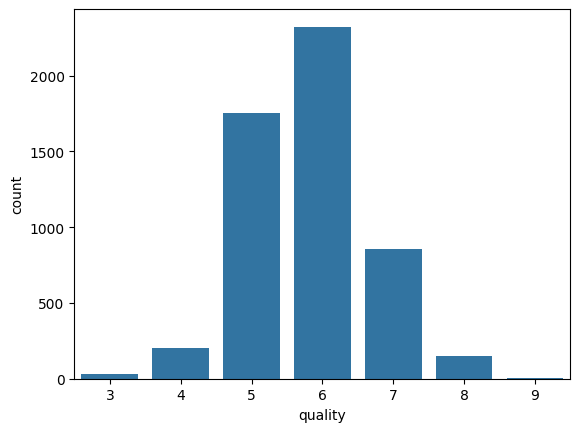

In [150]:
sns.countplot(x=y)

In [151]:
df.loc[:, 'quality'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

In [152]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [153]:
y_pred = model.predict(X_test)

In [154]:
y_test[:10]

622     1
4568    1
2901    1
3452    0
639     1
4631    1
610     0
4006    1
380     1
1468    0
Name: quality, dtype: int64

In [155]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6889097744360902
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.58      0.58       390
           1       0.76      0.75      0.75       674

    accuracy                           0.69      1064
   macro avg       0.67      0.67      0.67      1064
weighted avg       0.69      0.69      0.69      1064

Confusion Matrix:
 [[228 162]
 [169 505]]


In [156]:
train_score = model.score(X_train, y_train)
print("Training Accuracy:", train_score )
test_score = model.score(X_test, y_test)
print("Testing Accuracy:", test_score)


Training Accuracy: 0.6825657894736842
Testing Accuracy: 0.6889097744360902
